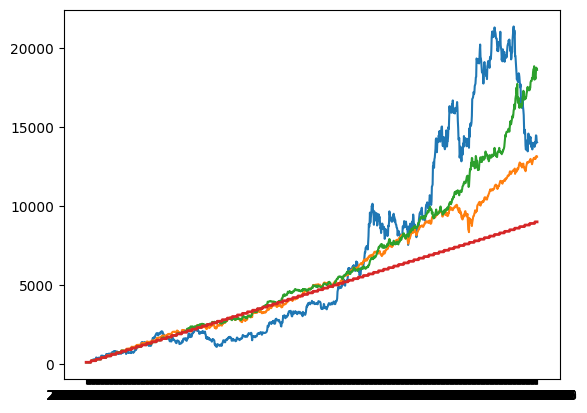

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

data = './BTC-market-analysis_2021-25.csv'
df = pd.read_csv(data)
df = df[["date", "btc_return", "sp500_return", "gold_return"]]

df = df.replace(0.000000, pd.NA)
df = df.dropna(subset=["sp500_return"])        
df = df.dropna(subset=["gold_return"])  

df["BTC Balance"] = 0.00000

df["SP500 Balance"] = 0.00000

df["Gold Balance"] = 0.00000

df["Invested Balance"] = 0.00000

size = len(df)

for i in range(size):  
    if i == 0:
        df.iloc[i,4] = 100
        df.iloc[i,5] = 100
        df.iloc[i,6] = 100
        df.iloc[i,7] = 100
    elif i % 14 == 0:
        line = df.iloc[i-1]
        df.iloc[i,4] = line["BTC Balance"] * (1 + line["btc_return"]) + 100
        df.iloc[i,5] = line["SP500 Balance"] * (1 + line["sp500_return"]) + 100
        df.iloc[i,6] = line["Gold Balance"] * (1 + line["gold_return"]) + 100
        df.iloc[i,7] = df.iloc[i-1,7] + 100
    else:
        line = df.iloc[i-1]
        df.iloc[i,4] = line["BTC Balance"] * (1 + line["btc_return"])
        df.iloc[i,5] = line["SP500 Balance"] * (1 + line["sp500_return"])
        df.iloc[i,6] = line["Gold Balance"] * (1 + line["gold_return"])
        df.iloc[i,7] = df.iloc[i-1,7]


plt.plot(df["date"], df["BTC Balance"])
plt.plot(df["date"], df["SP500 Balance"])
plt.plot(df["date"], df["Gold Balance"])
plt.plot(df["date"], df["Invested Balance"], linewidth=2)

plt.show()
